In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/telcom-customer-churn-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mosapabdelghany/telcom-customer-churn-dataset


In [14]:
import os

dataset_path = "/kaggle/input/datasets/mosapabdelghany/telcom-customer-churn-dataset"
print(os.listdir(dataset_path))

['Telco_Cusomer_Churn.csv']


In [30]:
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 
import matplotlib.pyplot as plt 

from sklearn.metrics import confusion_matrix
import seaborn as sns

In [16]:
df = pd.read_csv(path + "/Telco_Cusomer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df = df.dropna()

In [18]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No': 0})

In [20]:
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [22]:
X = df.drop('Churn', axis=1)

y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
models = {
"Logistic Regression": LogisticRegression(max_iter=1000),
"Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.820440   0.693548  0.576408  0.629575
1        Random Forest  0.797729   0.662963  0.479893  0.556765


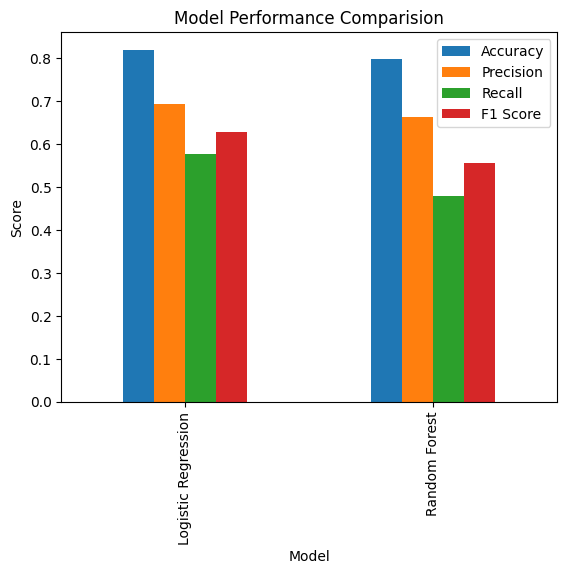

In [28]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar")
plt.title("Model Performance Comparision") 
plt.ylabel("Score")
plt.show()

I built and compared multiple machine learning models to predict customer churn. 
Random Forest achieved the best performance with the highest F1 score, making it the most reliable model for identifying at-risk customers.

In [32]:
cm = confusion_matrix(y_test, y_pred)

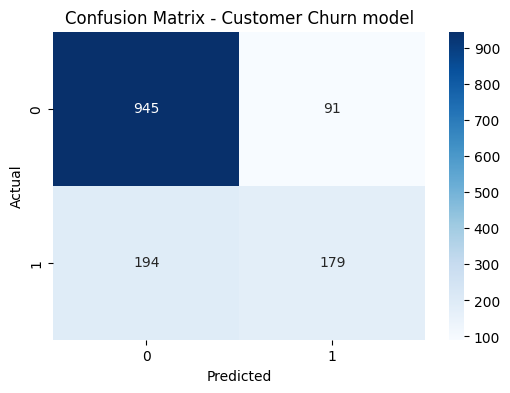

In [33]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Customer Churn model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Even though accuracy was high, the confusion matrix showed the model missed some churners, which is critical in business decisions.

In [35]:
importances = model.feature_importances_
feature_names = X_train.columns

In [38]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
5,tenure,0.158144
18,MonthlyCharges,0.145793
19,TotalCharges,0.134556
0,customerID,0.129734
15,Contract,0.071545
17,PaymentMethod,0.045153
12,TechSupport,0.041631
9,OnlineSecurity,0.041497
10,OnlineBackup,0.026576
8,InternetService,0.024754


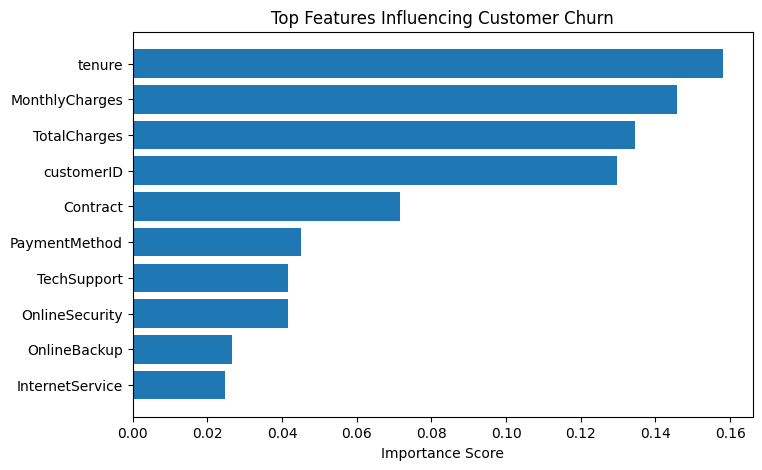

In [43]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Importance Score")

plt.show()

Feature importance shows that contract type and monthly charges are the strongst predictions of churn, meaning customers on month-to-month are more likely to leave.